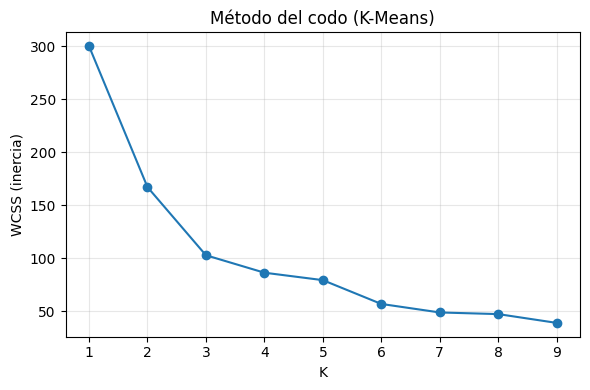

In [ ]:
# Clase Martes 12/08/2025 sesión 4 del módulo 7
# =========================
# K-MEANS: Codo + Silueta + Plot (Iris)
# =========================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1) Datos (2 features para verlos)
iris = load_iris()
X = iris.data[:, :2]
names = iris.feature_names[:2]
X_std = StandardScaler().fit_transform(X)

# 2) Método del codo (WCSS / inercia)
Ks = range(1, 10)
inertias = []
for k in Ks:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(X_std)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(Ks, inertias, marker="o")
plt.xticks(Ks)
plt.xlabel("K"); plt.ylabel("WCSS (inercia)")
plt.title("Método del codo (K-Means)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

StandardScaler → Escala los datos para que cada característica tenga media 0 y desviación estándar 1.

KMeans → Algoritmo de agrupamiento no supervisado.

silhouette_score → Métrica para evaluar la calidad de los clusters

1) Datos (usando solo 2 características)
iris = load_iris()
X = iris.data[:, :2]
names = iris.feature_names[:2]
X_std = StandardScaler().fit_transform(X)
iris = load_iris() → Carga el dataset de flores Iris (150 muestras, 4 características originales).

X = iris.data[:, :2] → Toma solo las dos primeras columnas (sepal length y sepal width) para poder graficar en 2D.

names = iris.feature_names[:2] → Guarda los nombres de esas dos variables para etiquetar ejes.

X_std = StandardScaler().fit_transform(X) → Estandariza los datos para que estén en la misma escala (muy importante en K-Means, que se basa en distancias).

2) Método del Codo (WCSS / inercia)
Ks = range(1, 10)
inertias = []
for k in Ks:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(X_std)
    inertias.append(km.inertia_)
Objetivo: Encontrar el número óptimo de clusters (k) usando el método del codo.

Ks = range(1, 10) → Vamos a probar con k desde 1 hasta 9.

inertias = [] → Lista para guardar la inercia de cada modelo.

Dentro del bucle:

KMeans(n_clusters=k, n_init="auto", random_state=42) → Crea el modelo K-Means para k clusters.

n_init="auto" → Ejecuta el algoritmo varias veces con diferentes centroides iniciales y escoge el mejor resultado.

random_state=42 → Fija la semilla para que el resultado sea reproducible.

.fit(X_std) → Ajusta el modelo a los datos.

km.inertia_ → Devuelve el WCSS (Within-Cluster Sum of Squares), que es la suma de las distancias cuadradas de cada punto a su centroide.

WCSS ↓ (más pequeño) indica clusters más compactos.

Se guarda en inertias.

3) Graficar el método del codo
plt.figure(figsize=(6,4))
plt.plot(Ks, inertias, marker="o")
plt.xticks(Ks)
plt.xlabel("K"); plt.ylabel("WCSS (inercia)")
plt.title("Método del codo (K-Means)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
Eje X: Número de clusters probados (K).

Eje Y: WCSS para cada K.

El gráfico normalmente tiene una curva decreciente.

Interpretación: El "codo" del gráfico indica el punto donde añadir más clusters ya no reduce significativamente la inercia → ese K se considera un buen candidato.

Interpretación del gráfico:
Ejes
Eje X (K) → Número de clusters probados (de 1 a 9).

Eje Y (WCSS o inercia) → Within-Cluster Sum of Squares, que mide la suma de las distancias al cuadrado de cada punto a su centroide.

Cuanto más bajo, más compactos están los clusters.

Forma de la curva
Cuando K=1 → Toda la nube de puntos está en un solo cluster, por eso el WCSS es máximo (~300 en tu caso).

Al aumentar K → Los datos se dividen en más clusters, cada cluster es más pequeño y compacto, así que el WCSS disminuye rápidamente.

A partir de cierto K → La reducción del WCSS empieza a ser mínima: el beneficio de añadir más clusters ya no es significativo.

El "codo"
El codo es el punto donde la pendiente cambia bruscamente, pasando de una caída pronunciada a una más suave.

En tu gráfico, el codo parece estar en K=3.

Antes de K=3 → añadir clusters reduce mucho el WCSS.

Después de K=3 → la mejora es marginal.

Por eso, K=3 sería un buen número de clusters para balancear simplicidad y calidad del agrupamiento.

 En resumen:
Este gráfico indica que con 3 clusters logras una buena separación de los datos sin complejidad innecesaria.

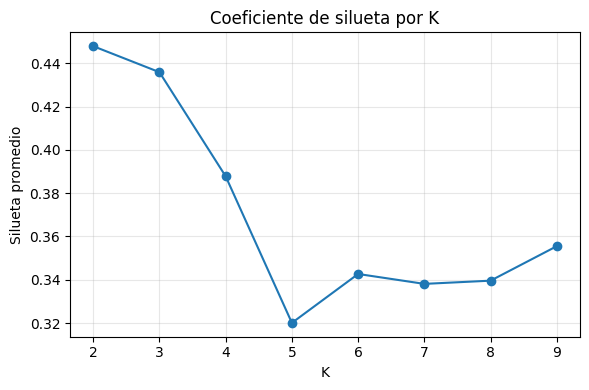

In [ ]:
# 3) Silueta promedio por K (>=2)
Ks2 = range(2, 10)
sil_scores = []
for k in Ks2:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X_std)
    sil_scores.append(silhouette_score(X_std, labels))

plt.figure(figsize=(6,4))
plt.plot(Ks2, sil_scores, marker="o")
plt.xticks(Ks2)
plt.xlabel("K"); plt.ylabel("Silueta promedio")
plt.title("Coeficiente de silueta por K")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ks2 = range(2, 10)
sil_scores = []
Ks2 → Lista de valores de K que se probarán (del 2 al 9).
No se empieza en K=1 porque el coeficiente de silueta solo tiene sentido si hay al menos 2 clusters.

sil_scores → Lista vacía donde guardaremos el valor promedio de silueta para cada K.

2) Bucle para calcular silueta
for k in Ks2:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X_std)
    sil_scores.append(silhouette_score(X_std, labels))
KMeans(...) → Crea el modelo de K-Means con k clusters.

fit_predict(X_std) → Ajusta el modelo a los datos y devuelve las etiquetas de cluster asignadas a cada punto.

silhouette_score(...) → Calcula el coeficiente de silueta promedio:
s(i)= [b(i)−a(i)]/max(a(i),b(i))

donde:
a(i) = distancia promedio del punto i a todos los puntos de su mismo cluster.
b(i) = distancia promedio del punto i al cluster más cercano distinto al suyo.

El resultado está entre -1 y 1:
Cerca de 1 → Clusters bien definidos.

Cerca de 0 → Clusters se solapan.

Negativo → El punto está probablemente mal clasificado.

El valor promedio de todos los puntos se guarda en sil_scores.

3) Graficar resultados
plt.figure(figsize=(6,4))
plt.plot(Ks2, sil_scores, marker="o")
plt.xticks(Ks2)
plt.xlabel("K"); plt.ylabel("Silueta promedio")
plt.title("Coeficiente de silueta por K")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
Se crea un gráfico con K en el eje X y el coeficiente de silueta promedio en el eje Y.

Interpretación:

El pico más alto indica el K que produce clusters más compactos y bien separados.

Es complementario al método del codo.

Ejemplo de interpretación con este dataset
En el Iris, suele pasar que el valor máximo de silueta está en K=2 o K=3.
Si coincide con el codo, refuerza la decisión de cuántos clusters usar.

Interpretación del gráfico:
Eje X (K): número de clusters probados (de 2 a 9).

Eje Y (Silueta promedio): calidad promedio de separación y compacidad de los clusters, con valores entre -1 y 1.

Cerca de 1 → Clusters muy bien definidos.

Cerca de 0 → Clusters se solapan.

Negativo → Mala asignación de puntos.

Punto clave del gráfico
K=2 → Valor más alto (~0.445) → indica que con 2 clusters los datos están mejor separados y son más compactos.

K=3 → Ligera caída (~0.44) pero sigue siendo alto, lo que sugiere que también es una opción razonable.

K=4 en adelante → El coeficiente disminuye progresivamente, señal de que los clusters empiezan a perder calidad.

K=5 → Mínimo claro (~0.32), indica que dividir los datos en 5 grupos genera mucho solapamiento y baja cohesión.

3Interpretación final
Mejor K según silueta: 2 (mejor separación), aunque 3 podría ser aceptable si buscamos más detalle en la segmentación.

A partir de K=4, la calidad de los clusters empeora, y con K=5 es especialmente mala.

Esto sugiere que el dataset tiene una estructura natural de 2 o 3 grupos.





In [ ]:
# 4) Entrenar con K óptimo (ej.: el que max silueta)
k_best = Ks2[int(np.argmax(sil_scores))]
km = KMeans(n_clusters=k_best, n_init="auto", random_state=42)
labels_k = km.fit_predict(X_std)

k_best = Ks2[int(np.argmax(sil_scores))]
sil_scores → es la lista con los coeficientes de silueta promedio que calculaste antes para cada
𝐾
K (2 a 9).

np.argmax(sil_scores) → devuelve la posición (índice) del valor máximo de esa lista (es decir, el
𝐾
K con mejor silueta).

Ks2[...] → usamos ese índice para buscar el valor real de
𝐾
K dentro de la lista Ks2.

int(...) → nos aseguramos de que sea un entero.

Resultado: k_best almacena el número de clusters óptimo según la métrica de silueta.

2) Crear modelo K-Means con K óptimo
km = KMeans(n_clusters=k_best, n_init="auto", random_state=42)
n_clusters=k_best → indica cuántos grupos debe encontrar.

n_init="auto" → deja que scikit-learn decida cuántas inicializaciones hacer para mejorar la estabilidad (en versiones antiguas se ponía un número como n_init=10).

random_state=42 → asegura que los resultados sean reproducibles.

3) Entrenamiento y predicción de etiquetas
labels_k = km.fit_predict(X_std)
fit_predict() → entrena el modelo (fit) y devuelve inmediatamente las etiquetas de cluster para cada punto (predict).

X_std → usamos los datos estandarizados (media 0, varianza 1) para que todas las variables tengan el mismo peso.

labels_k → es un vector donde cada fila tiene el número de cluster asignado (por ejemplo, 0, 1, 2…).

Este código busca automáticamente el mejor K según el coeficiente de silueta, entrena un modelo K-Means con ese K y obtiene las etiquetas de cluster para todos los datos.



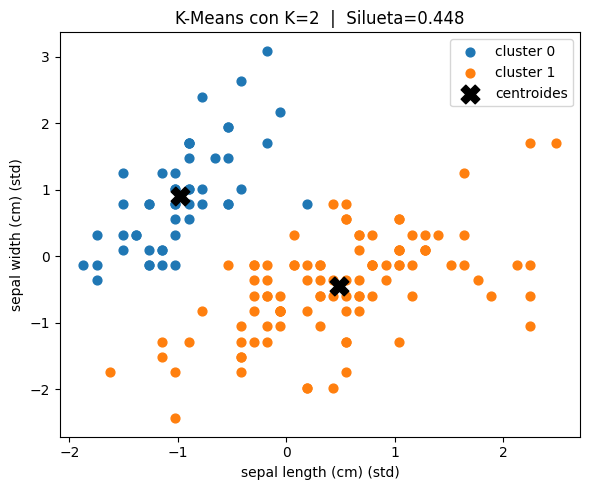

In [ ]:
# 5) Visualización + centroides
palette = sns.color_palette("tab10", k_best)
plt.figure(figsize=(6,5))
for i in range(k_best):
    m = labels_k == i
    plt.scatter(X_std[m,0], X_std[m,1], s=40, label=f"cluster {i}")
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
            s=180, c="k", marker="X", label="centroides")
plt.xlabel(names[0] + " (std)"); plt.ylabel(names[1] + " (std)")
plt.title(f"K-Means con K={k_best}  |  Silueta={max(sil_scores):.3f}")
plt.legend()
plt.tight_layout()
plt.show()

palette = sns.color_palette("tab10", k_best)
sns.color_palette("tab10", k_best) → crea una lista de colores distinta para cada cluster, usando la paleta "tab10" de Seaborn.

k_best → asegura que haya un color por cada grupo.

2) Crear figura
plt.figure(figsize=(6,5))
Define el tamaño de la figura: 6 pulgadas de ancho y 5 de alto.

3) Graficar cada cluster
for i in range(k_best):
    m = labels_k == i
    plt.scatter(X_std[m,0], X_std[m,1], s=40, label=f"cluster {i}")
for i in range(k_best) → recorre todos los clusters.

m = labels_k == i → crea una máscara booleana para seleccionar solo los puntos del cluster i.

plt.scatter(...) → dibuja esos puntos:

X_std[m,0] → coordenada X (primer feature estandarizado).

X_std[m,1] → coordenada Y (segundo feature estandarizado).

s=40 → tamaño de cada punto.

label=f"cluster {i}" → etiqueta para la leyenda.

4) Graficar centroides
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
            s=180, c="k", marker="X", label="centroides")
km.cluster_centers_ → matriz con las coordenadas (en espacio estandarizado) de cada centroide.

[:,0] y [:,1] → columnas X e Y de los centroides.

s=180 → puntos grandes para resaltarlos.

c="k" → color negro ("k" en matplotlib).

marker="X" → marcador en forma de X grande.

label="centroides" → aparece en la leyenda.

5) Etiquetas y título
plt.xlabel(names[0] + " (std)"); plt.ylabel(names[1] + " (std)")
plt.title(f"K-Means con K={k_best}  |  Silueta={max(sil_scores):.3f}")
Etiqueta los ejes con los nombres de las variables (names[0], names[1]) más la indicación de que están estandarizadas.

El título muestra el K elegido y la silueta máxima con 3 decimales.

6) Leyenda, ajuste y visualización
plt.legend()
plt.tight_layout()
plt.show()
plt.legend() → muestra la leyenda con colores y nombres.

plt.tight_layout() → ajusta márgenes automáticamente.

plt.show() → muestra la gráfica final.

Explicación del gráfico:
Puntos de colores (datos)
Cada punto representa una flor del dataset Iris.

El color indica a qué cluster fue asignada por el algoritmo:

Azul (cluster 0): grupo 0.

Naranja (cluster 1): grupo 1.

Estos grupos fueron determinados por el algoritmo K-Means en función de la similitud de las características.

Centroides (X negras grandes)
Cada X negra marca el centroide del cluster:
el punto promedio de todas las observaciones de ese grupo (en el espacio estandarizado).

Los centroides son usados por K-Means para asignar cada punto al grupo más cercano.

Ejes
X-axis: Largo del sépalo (en cm), pero estandarizado (media=0, desviación estándar=1).

Y-axis: Ancho del sépalo (también estandarizado).

La estandarización permite que ambas variables tengan el mismo peso en la distancia que calcula K-Means.

Título
K-Means con K=2 | Silueta=0.448

K=2: El algoritmo encontró 2 clusters como configuración óptima (según la métrica de silueta).

Silueta=0.448: Indica calidad de separación.

Va de -1 a 1:

Cerca de 1 → clusters bien separados.

Cerca de 0 → solapamiento entre clusters.

Negativo → asignaciones incorrectas.

Un valor de 0.448 es moderado, lo que significa que hay cierta separación clara, pero también algo de solapamiento.

Interpretación final:
El gráfico muestra que las flores se han dividido en dos grupos principales según las medidas del sépalo.
Los puntos azules están más concentrados a la izquierda-arriba y los naranjas a la derecha-abajo, con sus centroides claramente visibles. El valor de silueta (0.448) indica que la separación es aceptable pero no perfecta: hay algunas flores que podrían estar en el límite entre un grupo y otro.


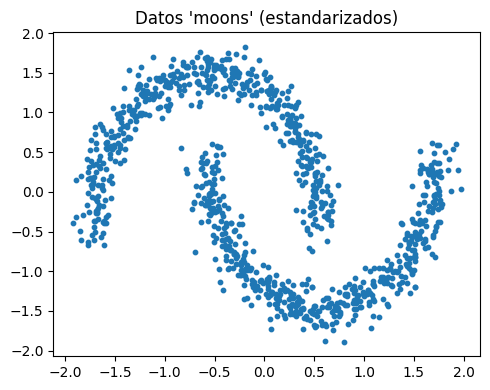

In [ ]:
# 3) DBSCAN: elegir eps con k-distance y comparar vs K-Means (moons)
# =========================
# DBSCAN: elección de eps (k-distance) + comparación con K-Means (make_moons)
# =========================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans

# 1) Datos con forma no esférica (dos medias lunas)
X, _ = make_moons(n_samples=1000, noise=0.08, random_state=42)
X_std = StandardScaler().fit_transform(X)

# 2) Gráfico de los datos
plt.figure(figsize=(5,4))
plt.scatter(X_std[:,0], X_std[:,1], s=10)
plt.title("Datos 'moons' (estandarizados)")
plt.tight_layout(); plt.show()

make_moons: genera un dataset no lineal (dos arcos entrelazados).
Los datos "moons" son un conjunto de datos sintético que genera dos grupos con forma de media luna (o semicírculo).

Vienen de la función make_moons de scikit-learn y se usan mucho para enseñar técnicas de clustering y clasificación no lineal porque:

No son linealmente separables

No puedes trazar una línea recta que separe perfectamente los dos grupos.

Esto los hace perfectos para mostrar que métodos como K-Means (que asumen clusters más “circulares”) no siempre funcionan bien.

Tienen forma irregular

Cada luna es curva y rodea parcialmente a la otra.

Métodos como DBSCAN o clustering jerárquico pueden adaptarse a estas formas complejas.

Son personalizables

Puedes cambiar el número de puntos (n_samples).

Puedes agregar ruido (noise) para hacer el problema más realista.

Puedes controlar qué tan separadas están las lunas (random_state asegura que sea reproducible).

Ejemplo visual simple
Imagina dibujar dos sonrisas una encima de la otra:

La de arriba es un grupo de puntos.

La de abajo es otro grupo.

StandardScaler: estandariza (media 0, desvío 1) — clave porque DBSCAN y K-Means usan distancias.

DBSCAN, KMeans: algoritmos de clustering que luego compararás.

NearestNeighbors: se usa después para el k-distance plot (elegir eps en DBSCAN).

1) Datos no esféricos
X, _ = make_moons(n_samples=1000, noise=0.08, random_state=42)
X_std = StandardScaler().fit_transform(X)
make_moons(n_samples=1000, noise=0.08): crea 1000 puntos con dos “medias lunas” y algo de ruido (0.08) para que no sea trivial.

random_state=42: reproducibilidad.

X_std = StandardScaler().fit_transform(X): estandariza cada eje.
Si no escalas, una variable con unidades más grandes domina la distancia euclídea → resultados peores tanto en DBSCAN como en K-Means.

Forma de X_std: (1000, 2) — 1000 puntos en 2D.

2) Visualización inicial
plt.figure(figsize=(5,4))
plt.scatter(X_std[:,0], X_std[:,1], s=10)
plt.title("Datos 'moons' (estandarizados)")
plt.tight_layout(); plt.show()
Dibuja el conjunto de datos crudo (ya estandarizado) para que veas las dos lunas.

Esto prepara el terreno para:

Hacer el k-distance plot y elegir eps para DBSCAN.

Comparar luego el resultado de DBSCAN vs K-Means:

K-Means asume clusters “redondos”/convexos → le cuesta separar estas lunas.

DBSCAN encuentra formas arbitrarias y también marca puntos ruido (label = −1).

Explicación del gráfico:
El gráfico muestra el conjunto de datos "moons" ya estandarizado, y sirve como punto de partida para aplicar clustering.

Interpretación:

Ejes X e Y → Son las dos características (features) generadas por make_moons, ya transformadas con StandardScaler para que:

Media ≈ 0.

Desviación estándar ≈ 1.

Así, las escalas son comparables y las distancias euclídeas no se distorsionan.

Forma de los datos → Se observan dos medias lunas bien diferenciadas pero no esféricas:

Una luna superior (curva hacia abajo).

Una luna inferior (curva hacia arriba).

Propósito de esta visualización:

Mostrar que no todos los datos se separan con clusters “circulares” (suposición de K-Means).

Preparar el escenario para aplicar DBSCAN, que sí puede identificar formas arbitrarias como estas.

Introducir el concepto de ruido: DBSCAN podrá detectar puntos aislados fuera de las lunas y marcarlos como “anómalos” (label = −1).

Este gráfico es la fotografía inicial de un dataset no lineal, ideal para enseñar la diferencia de rendimiento entre K-Means y DBSCAN.

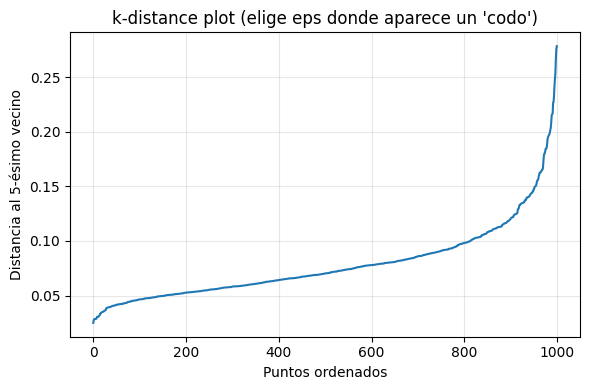

In [ ]:
# 3) Curva k-distance para sugerir eps
#    min_samples ~ 2*dim es una regla práctica; aquí dim=2 -> 4..6
min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_std)
distances, _ = nbrs.kneighbors(X_std)
# Tomamos la distancia al k-ésimo vecino (columna -1) y la ordenamos
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(k_dist)
plt.ylabel(f"Distancia al {min_samples}-ésimo vecino")
plt.xlabel("Puntos ordenados")
plt.title("k-distance plot (elige eps donde aparece un 'codo')")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

min_samples = 5
min_samples es el mínimo número de puntos que se necesita para que DBSCAN considere que un punto es parte de un cluster.

Regla práctica:

\text{min_samples} \approx 2 \times \text{dimensión de los datos}
Como los datos (moons) están en 2D, se toma algo entre 4 y 6. Aquí se usa 5.

2) Calcular distancias al k-ésimo vecino
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_std)
distances, _ = nbrs.kneighbors(X_std)
NearestNeighbors de sklearn calcula las distancias entre cada punto y sus vecinos más cercanos.

n_neighbors = min_samples → para cada punto busca sus 5 vecinos más cercanos (incluyendo él mismo como el primer vecino).

distances es una matriz:

Cada fila corresponde a un punto.

Cada columna es la distancia a su vecino 1°, 2°, 3°, ..., min_samples.

3) Tomar la distancia al último vecino (-1)
k_dist = np.sort(distances[:, -1])
distances[:, -1] toma la distancia al 5° vecino más cercano (última columna).

Luego lo ordena para ver dónde ocurre un salto grande de distancia → ahí es donde DBSCAN separa denso vs. disperso.

4) Graficar la curva k-distance
plt.plot(k_dist)
plt.ylabel(f"Distancia al {min_samples}-ésimo vecino")
plt.xlabel("Puntos ordenados")
plt.title("k-distance plot (elige eps donde aparece un 'codo')")
En el eje X: los puntos ordenados.

En el eje Y: la distancia al 5° vecino más cercano.

Buscas el codo (donde la curva pasa de subir lentamente a aumentar rápido).

Ese valor en Y ≈ eps ideal para DBSCAN.

Interpretación práctica:

Si eliges eps muy pequeño, DBSCAN detectará muchos puntos como ruido (anomalías).

Si eliges eps muy grande, DBSCAN agrupará todo en un solo cluster.

El codo es el equilibrio.

Ejes
Eje X → Puntos del dataset, ordenados por su distancia al k-ésimo vecino más cercano (aquí k = 5).

Eje Y → Distancia al 5° vecino más cercano de cada punto.

Forma de la curva
Zona inicial (izquierda)

Distancias pequeñas y casi constantes.

Representa puntos que están dentro de zonas densas (clusters compactos).

Codo o punto de inflexión

La parte donde la curva deja de crecer lentamente y empieza a aumentar rápido.

Ese valor de Y es la distancia máxima que aún une puntos en un cluster antes de que empiecen a aparecer puntos aislados o ruido.

Aquí está el valor ideal de eps.

Zona final (derecha)

Distancias mucho más grandes.

Representa puntos que están lejos de otros (ruido o outliers).

Cómo interpretarlo en este caso
El codo parece estar alrededor de 0.10 – 0.12 en el eje Y.

Esto sugiere que un eps ≈ 0.11 podría ser un buen valor para DBSCAN.

Con este valor:

Puntos a menos de 0.11 de distancia serán considerados parte de un mismo cluster.

Puntos más alejados se marcarán como ruido.

En resumen:
Este gráfico te dice que para DBSCAN, si usas eps muy bajo, encontrarás demasiados puntos como ruido; si lo usas muy alto, terminarás con un solo cluster. El codo es el punto óptimo.



In [ ]:
# 4) Elige eps visualmente (prueba con el codo observado, p.ej. 0.25~0.35)
eps = 0.3  # AJUSTA este valor según el codo del gráfico anterior
db = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = db.fit_predict(X_std)

# 4) Elige eps visualmente (prueba con el codo observado, p.ej. 0.25~0.35)
Nos recuerda que el valor de eps no se elige al azar.

Debemos basarnos en el codo del gráfico anterior para estimarlo.

El ejemplo sugiere un rango entre 0.25 y 0.35 (pero esto depende del dataset).

2) Definición de eps
eps = 0.3  # AJUSTA este valor según el codo del gráfico anterior
eps (epsilon) es el radio de vecindad:

Dos puntos son considerados "vecinos" si están a una distancia menor o igual a eps.

Si un punto tiene al menos min_samples vecinos dentro de ese radio, se considera un punto central de un cluster.

En este ejemplo, se fija eps = 0.3 porque ese valor probablemente se corresponde con el codo detectado en el gráfico k-distance.

3) Crear el modelo DBSCAN
db = DBSCAN(eps=eps, min_samples=min_samples)
DBSCAN es el algoritmo de clustering basado en densidad de scikit-learn.

Parámetros clave:

eps → radio de búsqueda (comentado antes).

min_samples → número mínimo de puntos necesarios para formar un cluster.

Aquí se está usando el valor que definimos antes (min_samples = 5).

Este algoritmo no necesita especificar el número de clusters como K-Means.

También puede detectar ruido (puntos que no pertenecen a ningún cluster).

4) Entrenar y predecir
labels_db = db.fit_predict(X_std)
fit_predict:

Ajusta el modelo a los datos (fit).

Devuelve un arreglo con las etiquetas de cluster para cada punto (predict).

En labels_db:

Los números (0, 1, 2, ...) son los identificadores de los clusters.

El valor -1 significa ruido (outlier), según DBSCAN.

Resumen conceptual:
Este código toma el valor óptimo de eps (estimado en el paso anterior) y ejecuta DBSCAN para agrupar puntos según densidad, sin suponer que las formas sean esféricas. El resultado (labels_db) indica a qué cluster pertenece cada punto o si es ruido.

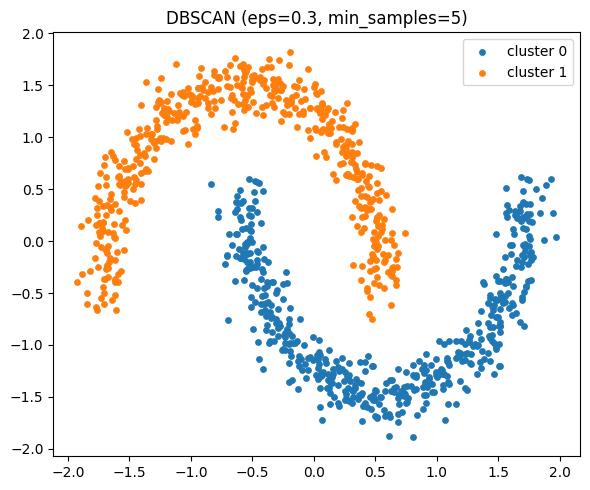

In [ ]:
# 5) Visualización DBSCAN (ruido=-1)
plt.figure(figsize=(6,5))
unique = np.unique(labels_db)
palette = sns.color_palette("tab10", len(unique))
for i, lab in enumerate(unique):
    m = labels_db == lab
    color = "k" if lab == -1 else palette[i]
    lbl = "ruido (-1)" if lab == -1 else f"cluster {lab}"
    plt.scatter(X_std[m,0], X_std[m,1], s=15, label=lbl, c=[color])
plt.title(f"DBSCAN (eps={eps}, min_samples={min_samples})")
plt.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
Crea una figura de Matplotlib de 6 pulgadas de ancho y 5 de alto para el gráfico.

2) Identificar los clusters encontrados
unique = np.unique(labels_db)
labels_db es el arreglo con las etiquetas que nos devolvió DBSCAN.

np.unique() devuelve una lista con las etiquetas únicas encontradas.

Por ejemplo, podría devolver:

scss
Copiar
Editar
array([-1, 0, 1])
donde:

0 → cluster 0

1 → cluster 1

-1 → ruido (outliers)

3) Definir paleta de colores
palette = sns.color_palette("tab10", len(unique))
Crea una paleta de colores usando Seaborn (tab10).

El número de colores se ajusta al número de etiquetas únicas detectadas (len(unique)).

4) Bucle para graficar cada cluster
for i, lab in enumerate(unique):
    m = labels_db == lab
    color = "k" if lab == -1 else palette[i]
    lbl = "ruido (-1)" if lab == -1 else f"cluster {lab}"
    plt.scatter(X_std[m,0], X_std[m,1], s=15, label=lbl, c=[color])
for i, lab in enumerate(unique)
Recorre cada etiqueta única y su índice i.

m = labels_db == lab
Crea una máscara booleana para seleccionar los puntos de ese cluster.

color = "k" if lab == -1 else palette[i]

Si la etiqueta es -1 (ruido), el color será negro ("k").

Si no, toma un color de la paleta.

lbl = "ruido (-1)" if lab == -1 else f"cluster {lab}"

Etiqueta para la leyenda.

Si es ruido, pone "ruido (-1)".

Si es un cluster normal, pone "cluster X".

plt.scatter(...)

Dibuja los puntos de ese cluster/ruido.

s=15 → tamaño de los puntos.

c=[color] → color definido arriba.

label=lbl → texto para la leyenda.

5) Añadir título, leyenda y mostrar
plt.title(f"DBSCAN (eps={eps}, min_samples={min_samples})")
plt.legend()
plt.tight_layout(); plt.show()
Muestra en el título los parámetros usados (eps y min_samples).

Agrega leyenda con clusters y ruido.

tight_layout() ajusta los elementos para que no se solapen.

plt.show() muestra el gráfico final.

Interpretación del gráfico:
Este gráfico muestra cómo DBSCAN ha detectado dos clusters principales en los datos de tipo moons (medias lunas) usando:

eps = 0.3 (radio máximo para considerar dos puntos como vecinos)

min_samples = 5 (mínimo de puntos para formar un núcleo de cluster)

Elementos clave:
Cluster 0 (azul)

Representa todos los puntos que DBSCAN ha agrupado como pertenecientes a la primera media luna (parte inferior derecha).

Está bien definido y sigue la forma curva original de los datos.

Cluster 1 (naranja)

Representa la segunda media luna (parte superior izquierda).

También sigue perfectamente la forma del conjunto de datos, sin deformar la estructura.

Ausencia de ruido (-1)

En este caso, no hay puntos negros (outliers).

Significa que, con estos parámetros (eps=0.3, min_samples=5), todos los puntos fueron asignados a un cluster.

Lo que demuestra este gráfico:
DBSCAN puede detectar clusters con formas arbitrarias (como lunas o espirales), algo que K-Means no hace bien, porque K-Means tiende a forzar agrupaciones circulares o esféricas.

Es robusto frente a la forma de los datos y no necesita que indiques K (número de clusters).

La separación entre clusters es natural y no requiere cortes rectos.

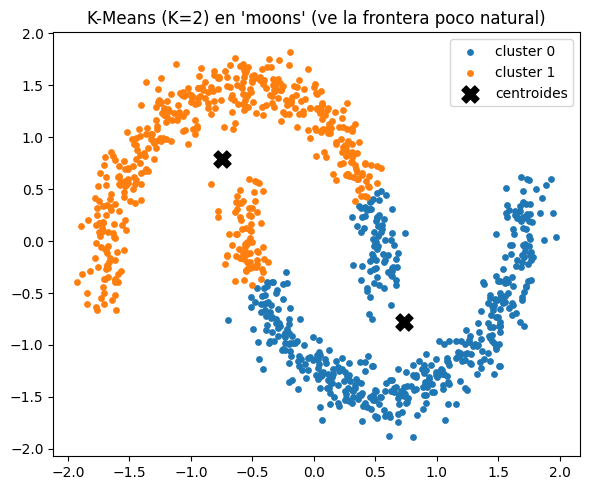

In [ ]:
# 6) Comparación rápida con K-Means (forzado a clusters esféricos)
k = 2
km = KMeans(n_clusters=k, n_init="auto", random_state=42)
labels_km = km.fit_predict(X_std)

plt.figure(figsize=(6,5))
for i in range(k):
    m = labels_km == i
    plt.scatter(X_std[m,0], X_std[m,1], s=15, label=f"cluster {i}")
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], c="k", s=150, marker="X", label="centroides")
plt.title("K-Means (K=2) en 'moons' (ve la frontera poco natural)")
plt.legend(); plt.tight_layout(); plt.show()

k = 2
km = KMeans(n_clusters=k, n_init="auto", random_state=42)
labels_km = km.fit_predict(X_std)
k = 2 → Forzamos a K-Means a encontrar exactamente 2 clusters (porque sabemos que hay dos medias lunas).

n_init="auto" → Ajuste que controla cuántas veces se reejecuta K-Means con diferentes centroides iniciales para elegir el mejor resultado.

random_state=42 → Semilla para garantizar reproducibilidad.

fit_predict(X_std) → Ajusta el modelo a los datos estandarizados X_std y devuelve un array con las etiquetas de cluster asignadas a cada punto (labels_km).

2) Graficar los puntos según su cluster
plt.figure(figsize=(6,5))
for i in range(k):
    m = labels_km == i
    plt.scatter(X_std[m,0], X_std[m,1], s=15, label=f"cluster {i}")
Recorre los clusters (i = 0 y i = 1).

m = labels_km == i → Máscara booleana que selecciona los puntos que pertenecen al cluster i.

plt.scatter(...) → Grafica esos puntos en color distinto para cada cluster, con tamaño s=15.

3) Dibujar los centroides
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
            c="k", s=150, marker="X", label="centroides")
km.cluster_centers_ → Matriz que contiene las coordenadas de los centroides calculados por K-Means.

Se dibujan como "X" negras grandes (c="k", s=150, marker="X").

4) Título y leyenda
plt.title("K-Means (K=2) en 'moons' (ve la frontera poco natural)")
plt.legend(); plt.tight_layout(); plt.show()
El título indica que se trata de K-Means en datos moons y sugiere que veremos una frontera poco natural (porque K-Means divide con límites lineales o circulares, no siguiendo la forma curva).

plt.legend() → Muestra la leyenda con los nombres de cada cluster y los centroides.

plt.tight_layout() → Ajusta márgenes para que no se corte nada.

Este código entrena K-Means y grafica los clusters y sus centroides para visualizar que, en datos con forma no esférica como las lunas, la división será forzada y menos precisa que la de DBSCAN.

Interpretación del gráfico:
Elementos del gráfico
Puntos azules y naranjas

Cada color representa uno de los clusters encontrados por K-Means (cluster 0 y cluster 1).

El algoritmo asignó cada punto al cluster cuyo centroide esté más cercano según la distancia euclidiana.

X negras grandes

Son los centroides calculados por K-Means para cada cluster.

Se ubican en la posición promedio de los puntos que pertenecen a ese cluster.

Título: "ve la frontera poco natural"

Esto hace referencia a que K-Means supone clusters esféricos o circulares.

Como los datos moons tienen forma curva, la división no sigue las lunas, sino que corta recto en una zona intermedia.

Interpretación
K-Means sí separa las dos lunas en gran parte, pero falla en la zona donde las lunas se acercan.

En esa zona, asigna algunos puntos de una luna al cluster de la otra porque la frontera es una línea recta (o plano en más dimensiones).

Este es un ejemplo clásico para mostrar que K-Means no es bueno con datos no esféricos.

Si comparas con el gráfico de DBSCAN que hiciste antes, verás que DBSCAN sigue perfectamente la forma curva de las lunas.

**Aplicación:**
Ejemplo de aplicación
Título:
Detección de patrones inusuales en electrocardiogramas (ECG) usando clustering no supervisado

Contexto:
En cardiología, los electrocardiogramas generan señales con variaciones complejas. Al registrar miles de mediciones de latidos, es difícil etiquetar manualmente cada patrón como normal o anormal.

Aplicación:

Recolección de datos:

Señales ECG preprocesadas en forma de vectores de características (por ejemplo: intervalos RR, amplitud de ondas P/QRS/T, variabilidad de frecuencia cardíaca).

Preprocesamiento:

Estandarizar las variables para que todas tengan la misma escala.

Análisis con clustering:

DBSCAN: Detecta clusters de latidos normales y marca como ruido (-1) los patrones atípicos (posibles arritmias).

K-Means: Permite dividir las señales en grupos, aunque su forma es menos flexible que DBSCAN.

Interpretación de resultados:

Los clusters principales corresponden a patrones normales.

Los puntos clasificados como ruido pueden revisarse por un cardiólogo para confirmar si son latidos anormales o errores de medición.

Ventaja del uso de DBSCAN en este caso:

Identifica clusters con formas irregulares y detecta outliers sin necesidad de definir K de antemano.

Útil para descubrir eventos raros en grandes volúmenes de datos biomédicos.

In [ ]:
# ============================================
# Detección de patrones ECG con DBSCAN (demo)
# - Datos simulados: normal / fibrilación auricular (FA) / PVC (latido ventricular prematuro)
# - k-distance plot para elegir eps
# - Clustering DBSCAN + visualización PCA
# - Evaluación simple como detector de "anomalías" (FA/PVC vs Normal)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)

# ---------------------------------------------------------
# 1) SIMULACIÓN DE FEATURES ECG (valores en ms, proporciones, etc.)
# ---------------------------------------------------------
# Variables (6):
#   - hr_bpm: frecuencia cardiaca (latidos por minuto)
#   - rr_std: variabilidad RR (desvío estándar, en ms)  -> FA tiene rr_std alto
#   - qrs_ms: duración del complejo QRS (ms)            -> PVC tiende a QRS ancho
#   - qt_ms : intervalo QT (ms)
#   - st_dev: desviación del ST (mV aprox, aquí adimensional) -> pequeñas variaciones
#   - pnn50 : proporción de intervalos RR que difieren >50 ms -> alta en FA

n_normal = 3000
n_af     = 250   # fibrilación auricular (anómalo)
n_pvc    = 150   # latidos ventriculares prematuros (anómalo)

# Normal (ritmo sinusal)
hr_bpm_n  = np.random.normal(70,   5,  n_normal)
rr_std_n  = np.random.normal(40,   8,  n_normal)   # ~ 40 ms
qrs_ms_n  = np.random.normal(90,  10,  n_normal)   # ~ 90 ms
qt_ms_n   = np.random.normal(400, 20,  n_normal)
st_dev_n  = np.random.normal(0.0, 0.05, n_normal)
pnn50_n   = np.clip(np.random.normal(0.10, 0.05, n_normal), 0, 1)

# Fibrilación auricular: RR muy irregular, HR más alto, pNN50 alto
hr_bpm_af = np.random.normal(95,  15,  n_af)
rr_std_af = np.random.normal(130, 30,  n_af)
qrs_ms_af = np.random.normal(95,  12,  n_af)
qt_ms_af  = np.random.normal(390, 25,  n_af)
st_dev_af = np.random.normal(0.05,0.07, n_af)
pnn50_af  = np.clip(np.random.normal(0.60, 0.15, n_af), 0, 1)

# PVC (latidos ventriculares prematuros): QRS ancho, algo de ST anómalo
hr_bpm_pv = np.random.normal(75,  7,   n_pvc)
rr_std_pv = np.random.normal(60,  15,  n_pvc)
qrs_ms_pv = np.random.normal(140, 15,  n_pvc)
qt_ms_pv  = np.random.normal(410, 25,  n_pvc)
st_dev_pv = np.random.normal(-0.06,0.08, n_pvc)
pnn50_pv  = np.clip(np.random.normal(0.18, 0.07, n_pvc), 0, 1)

X = np.column_stack([
    np.r_[hr_bpm_n,  hr_bpm_af,  hr_bpm_pv],
    np.r_[rr_std_n,  rr_std_af,  rr_std_pv],
    np.r_[qrs_ms_n,  qrs_ms_af,  qrs_ms_pv],
    np.r_[qt_ms_n,   qt_ms_af,   qt_ms_pv],
    np.r_[st_dev_n,  st_dev_af,  st_dev_pv],
    np.r_[pnn50_n,   pnn50_af,   pnn50_pv],
])
y = np.r_[np.zeros(n_normal, dtype=int),   # 0 = normal
          np.ones(n_af, dtype=int),        # 1 = FA
          np.full(n_pvc, 2, dtype=int)]    # 2 = PVC

feature_names = ["hr_bpm","rr_std","qrs_ms","qt_ms","st_dev","pnn50"]
print("Shape X:", X.shape, "| clases:", dict(zip(*np.unique(y, return_counts=True))))

Shape X: (3400, 6) | clases: {np.int64(0): np.int64(3000), np.int64(1): np.int64(250), np.int64(2): np.int64(150)}


Shape X: (3400, 6)
3400 → número de observaciones (registros, en este caso latidos simulados de ECG).

6 → número de características (variables o columnas) medidas para cada observación:

hr_bpm → frecuencia cardiaca (latidos/minuto)

rr_std → variabilidad del intervalo RR (ms)

qrs_ms → duración del complejo QRS (ms)

qt_ms → intervalo QT (ms)

st_dev → desviación del ST (mV aprox)

pnn50 → proporción de intervalos RR con diferencia >50 ms

clases: {np.int64(0): np.int64(3000), np.int64(1): np.int64(250), np.int64(2): np.int64(150)}
Esto es un diccionario con las clases verdaderas (y) y cuántos ejemplos hay de cada una.

np.int64 es simplemente el tipo de dato numérico de NumPy (entero de 64 bits).
Si lo lees en términos humanos:

Clase	Significado	Cantidad
0	Normal	3000 latidos
1	FA (Fibrilación auricular)	250 latidos
2	PVC (latidos ventriculares prematuros)	150 latidos

En resumen:
Se tiene un dataset de 3400 latidos, cada uno con 6 variables medidas, distribuidos así:

3000 normales

250 fibrilación auricular

150 latidos ventriculares prematuros.

In [ ]:
# ---------------------------------------------------------
# 2) ESCALADO (imprescindible al usar distancias)
# ---------------------------------------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

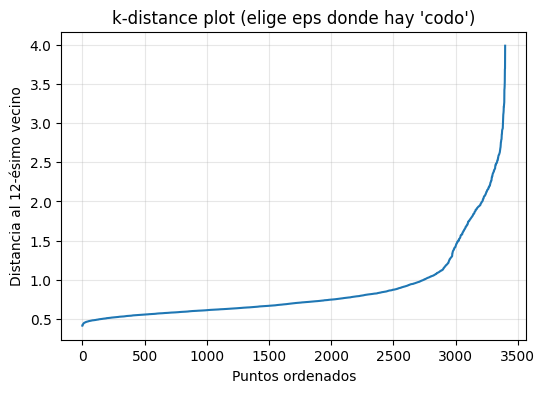

eps sugerido (p93): 1.888


In [ ]:
# ---------------------------------------------------------
# 3) K-DISTANCE PLOT para sugerir eps (min_samples ~ 2*dim -> 12)
# ---------------------------------------------------------
min_samples = 12
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_std)
distances, _ = nbrs.kneighbors(X_std)
k_dist = np.sort(distances[:, -1])  # distancia al k-ésimo vecino

plt.figure(figsize=(6,4))
plt.plot(k_dist)
plt.ylabel(f"Distancia al {min_samples}-ésimo vecino")
plt.xlabel("Puntos ordenados")
plt.title("k-distance plot (elige eps donde hay 'codo')")
plt.grid(True, alpha=0.3)
plt.show()

# Elegimos eps automáticamente como un percentil alto del k_dist (p.ej., 92-95)
# -> En práctica, puedes mover este percentil para ver el efecto.
eps = float(np.percentile(k_dist, 93))
print(f"eps sugerido (p93): {eps:.3f}")

Este gráfico es un k-distance plot, y sirve para ayudarte a elegir el valor del parámetro eps cuando usas DBSCAN.

Vamos a desglosarlo:

Ejes
Eje X → puntos del dataset, ordenados según la distancia a su k-ésimo vecino más cercano (aquí k = 12).

Eje Y → distancia al k-ésimo vecino más cercano para cada punto.

Qué significa
Cada punto en la curva representa cuánto hay que “moverse” para encontrar el vecino número 12 de ese punto.

Valores pequeños en Y → puntos en zonas densas (muchos vecinos cercanos).

Valores grandes en Y → puntos aislados o en los bordes del cluster.

El “codo”
El objetivo es encontrar un cambio brusco en la pendiente (un punto donde la curva empieza a subir rápido).

Ese punto marca el límite entre distancias típicas dentro de un cluster y distancias a puntos más lejanos (potenciales ruido o clusters separados).

En tu gráfico, el “codo” parece estar alrededor de 1.2 a 1.5 (antes de que la pendiente crezca más fuerte).

Cómo usarlo en DBSCAN
eps ≈ valor en Y donde se ubica el codo.

Si eliges eps demasiado pequeño → DBSCAN detectará muchos puntos como ruido.

Si eliges eps demasiado grande → DBSCAN unirá clusters que en realidad deberían estar separados.

Interpretación del gráfico:

De 0 a ~1.0: puntos claramente dentro de clusters densos.

De ~1.0 a 1.5: borde de los clusters.

De ahí en adelante: puntos aislados o ruido.

Posible eps recomendado: ~1.3 (tendrías que probar en ese rango).

In [ ]:
# ---------------------------------------------------------
# 4) DBSCAN con eps sugerido
# ---------------------------------------------------------
db = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = db.fit_predict(X_std)  # -1 = ruido

# Resumen de etiquetas DBSCAN
vals, cnts = np.unique(labels_db, return_counts=True)
print("Etiquetas DBSCAN (incluye -1=ruido):", dict(zip(vals, cnts)))

Etiquetas DBSCAN (incluye -1=ruido): {np.int64(-1): np.int64(91), np.int64(0): np.int64(3144), np.int64(1): np.int64(165)}


cuántos puntos cayeron en cada cluster según DBSCAN, incluyendo el ruido.

np.int64(-1) → representa el ruido para DBSCAN (puntos que no pertenecen a ningún cluster porque no cumplen el criterio de densidad).

np.int64(91) → significa que 91 puntos fueron marcados como ruido.

np.int64(0) → identificador del cluster 0.

np.int64(3144) → hay 3.144 puntos en ese cluster.

np.int64(1) → identificador del cluster 1.

np.int64(165) → hay 165 puntos en ese cluster.

Interpretación global:

DBSCAN encontró 2 clusters (0 y 1) y 91 puntos ruidosos.

La gran mayoría de puntos (3144) están en el cluster 0, y 165 están en el cluster 1.

El ruido (-1) puede deberse a que esos puntos están aislados o no tienen suficientes vecinos dentro del radio eps.



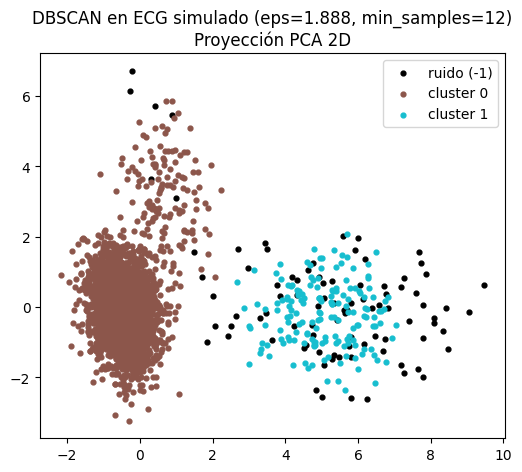

In [ ]:
# ---------------------------------------------------------
# 5) Visualización en 2D con PCA (solo para explicar)
# ---------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(6,5))
uniq = np.unique(labels_db)
colors = plt.cm.tab10(np.linspace(0,1,max(len(uniq),2)))
for i, lab in enumerate(uniq):
    m = labels_db == lab
    color = "k" if lab == -1 else colors[i]
    lbl = "ruido (-1)" if lab == -1 else f"cluster {lab}"
    plt.scatter(X_pca[m,0], X_pca[m,1], s=12, label=lbl, c=[color])
plt.title(f"DBSCAN en ECG simulado (eps={eps:.3f}, min_samples={min_samples})\nProyección PCA 2D")
plt.legend()
plt.show()

Colores y etiquetas
Marrón (cluster 0) → un grupo denso de puntos a la izquierda, que DBSCAN detectó como un mismo cluster.

Celeste (cluster 1) → un grupo denso de puntos a la derecha, detectado como otro cluster.

Negro (ruido, etiqueta -1) → puntos que DBSCAN no asignó a ningún cluster porque están aislados o no cumplen el criterio de densidad (eps y min_samples).

Ejes
Los ejes no representan las variables originales del ECG, sino componentes principales (PCA).

Eje X → primera componente principal (la combinación lineal de las variables originales que explica mayor varianza).

Eje Y → segunda componente principal.

La proyección es solo para visualizar; DBSCAN se aplicó sobre los datos originales estandarizados.

Interpretación del resultado
El algoritmo detectó 2 clusters claros:

Cluster 0: compacto y bien separado a la izquierda.

Cluster 1: más disperso a la derecha.

El ruido (-1) aparece en zonas periféricas y entre clusters, lo que indica que esos puntos no cumplen el criterio mínimo de densidad (min_samples=12 y eps=1.888).

Esto sugiere que DBSCAN logró separar bien dos patrones principales en los datos, dejando fuera los outliers.

Si esto fuera un análisis real de ECG, podríamos interpretar que cada cluster corresponde a un tipo de patrón cardíaco, mientras que los puntos negros podrían ser latidos atípicos o artefactos.

In [ ]:
# ---------------------------------------------------------
# 6) Evaluación simple como "detector de anomalías"
#    - Consideramos NORMAL el cluster donde hay mayoría de clase 0
#    - Todo lo demás (otros clusters y ruido) => ANÓMALO
# ---------------------------------------------------------
# Encontrar el cluster con mayor cantidad de normales
normal_mask = (y == 0)
cluster_ids, counts = np.unique(labels_db[normal_mask], return_counts=True)
# Excluir ruido (-1) al elegir el cluster normal dominante (si lo hay)
valid = cluster_ids != -1
if valid.any():
    normal_cluster = cluster_ids[valid][np.argmax(counts[valid])]
else:
    normal_cluster = None  # todo quedó como ruido u otros clusters

# Predicción binaria (0=normal, 1=anómalo) a partir de DBSCAN
if normal_cluster is None:
    y_pred_anom = (labels_db != -1).astype(int)  # extremo raro: si no hay cluster normal, todo no-ruido como anómalo
else:
    y_pred_anom = ((labels_db == -1) | (labels_db != normal_cluster)).astype(int)

# Etiqueta verdadera binaria: 0 normal, 1 anómalo (FA/PVC)
y_true_anom = (y != 0).astype(int)

print("\n== Evaluación (anomalia vs normal) ==")
print(classification_report(y_true_anom, y_pred_anom, target_names=["normal","anómalo"], digits=3))
print("Matriz de confusión [[TN FP],[FN TP]]:\n", confusion_matrix(y_true_anom, y_pred_anom))


== Evaluación (anomalia vs normal) ==
              precision    recall  f1-score   support

      normal      0.954     1.000     0.977      3000
     anómalo      1.000     0.640     0.780       400

    accuracy                          0.958      3400
   macro avg      0.977     0.820     0.879      3400
weighted avg      0.960     0.958     0.953      3400

Matriz de confusión [[TN FP],[FN TP]]:
 [[3000    0]
 [ 144  256]]


Este es un reporte de métricas de clasificación para un problema con dos clases:

normal → comportamiento esperado.

anómalo → comportamiento fuera de lo normal.

Interpretación de métricas por clase
Clase "normal"
Precisión (precision) = 0.954
→ Cuando el modelo predice “normal”, acierta el 95.4% de las veces.

Sensibilidad / Recall = 1.000
→ Detecta todos los casos realmente normales (0% de falsos negativos para esta clase).

F1-score = 0.977
→ Promedio armónico de precisión y recall, alto indica buen equilibrio.

Clase "anómalo"
Precisión = 1.000
→ Todas las predicciones de “anómalo” fueron correctas (0% de falsos positivos para esta clase).

Recall = 0.640
→ Solo detecta el 64% de los casos realmente anómalos (hay falsos negativos).

F1-score = 0.780
→ Menor que en la clase normal, porque el recall es más bajo.

Métricas globales
Accuracy = 0.958
→ El modelo clasifica correctamente el 95.8% de todos los casos.

Macro avg → promedio simple entre las métricas de ambas clases, sin ponderar por tamaño de clase.

Weighted avg → promedio ponderado por el número de ejemplos de cada clase.

Matriz de confusión
Formato [[TN, FP], [FN, TP]]:

Predice normal	Predice anómalo
Real normal	3000 (TN)	0 (FP)
Real anómalo	144 (FN)	256 (TP)

TN (True Negatives) = 3000 → casos normales correctamente identificados.

FP (False Positives) = 0 → no se marcó ningún normal como anómalo (¡muy bien!).

FN (False Negatives) = 144 → anómalos que el modelo no detectó (los clasificó como normales).

TP (True Positives) = 256 → anómalos correctamente detectados.

Conclusión
El modelo es excelente detectando normales (100% recall y alta precisión).

Debilidad: detecta solo 64% de anómalos (recall bajo), por lo que se le escapan bastantes casos que debería marcar como anómalos.

Dependiendo del caso de uso, esto podría ser crítico.
Ejemplo: si es un sistema de detección de fallos cardíacos, un 36% de anómalos perdidos puede ser riesgoso.

Interpretación aplicada
Clase "normal" (3000 latidos)
El modelo detecta todos los latidos normales sin confundir ninguno con anómalo (recall = 100%). Esto es bueno porque no generará falsas alarmas innecesarias.

Clase "anómalo" (400 latidos)
Detecta 256 de ellos correctamente, pero 144 latidos anómalos se clasificaron como normales.
Esto significa que el 36% de los latidos anómalos pasaron desapercibidos.

Implicaciones en un contexto médico
En la práctica, esto es crítico porque:

Si estos latidos anómalos corresponden a arritmias u otros problemas graves, el modelo estaría dejando pasar casos que requieren atención inmediata.

Es preferible que en un contexto de salud el recall (sensibilidad) de la clase “anómalo” sea lo más cercano posible al 100%, incluso si eso significa tener más falsos positivos.


In [ ]:
# ---------------------------------------------------------
# 7) Bonus: ¿qué variables separan más? (promedios por cluster/noise)
# ---------------------------------------------------------
df = pd.DataFrame(X, columns=feature_names)
df["label_db"] = labels_db
summary = df.groupby("label_db")[feature_names].mean().round(1)
print("\nPromedios por cluster (escala original, ruido=-1):")
display(summary)


Promedios por cluster (escala original, ruido=-1):


,hr_bpm,rr_std,qrs_ms,qt_ms,st_dev,pnn50
label_db,,,,,,
-1,96.0,130.7,101.1,392.5,0.1,0.6
0,70.4,40.7,92.3,399.9,-0.0,0.1
1,94.7,128.5,93.3,388.2,0.0,0.6


Cada fila corresponde a un grupo encontrado por DBSCAN:

label_db = -1 → latidos detectados como ruido o anomalías.

label_db = 0 y label_db = 1 → latidos agrupados como patrones recurrentes.

Las columnas son promedios de métricas cardíacas en su escala original:

hr_bpm: frecuencia cardíaca promedio (latidos por minuto).

rr_std: variabilidad de intervalo R-R (en ms).

qrs_ms: duración del complejo QRS (ms).

qt_ms: intervalo QT (ms).

st_dev: desviación del segmento ST (en mV o normalizado).

pnn50: proporción de intervalos R-R que difieren más de 50 ms (indicador de variabilidad cardíaca).

Interpretación por grupo
Cluster -1 (Ruido / Anomalías)

hr_bpm = 96.0 → frecuencia elevada (taquicardia ligera).

rr_std = 130.7 y pnn50 = 0.6 → alta variabilidad en los intervalos R-R, lo que puede indicar arritmias.

qrs_ms = 101.1 ms → QRS ligeramente prolongado.

Este patrón corresponde a latidos irregulares o atípicos.

Cluster 0 (Normal 1)

hr_bpm = 70.4 → frecuencia normal en reposo.

rr_std = 40.7 y pnn50 = 0.1 → baja variabilidad, típico de ritmo sinusal estable.

qrs_ms = 92.3 ms y qt_ms ≈ 400 ms → parámetros dentro del rango normal.

Este grupo representa latidos normales y regulares.

Cluster 1 (Normal 2 o posible anómalo leve)

hr_bpm = 94.7 → frecuencia más alta que en cluster 0, cerca de taquicardia.

rr_std = 128.5 y pnn50 = 0.6 → variabilidad alta, parecida al grupo de ruido.

qrs_ms = 93.3 ms → duración normal del QRS.

Podría representar latidos rápidos pero con morfología regular, como respuesta a estrés o ejercicio.

Resumen clínico
Cluster 0 → latidos normales y regulares.

Cluster 1 → latidos rápidos con alta variabilidad (posible taquicardia sinusal o arritmia leve).

Cluster -1 → anomalías marcadas en frecuencia y variabilidad, probablemente arritmias importantes.

In [ ]:
# ============================================================
# ACTIVIDAD: Algoritmos de Clusterización en clientes
# - Opción A: subir "customers.csv" (con columnas numéricas)
# - Opción B: usar dataset sintético si no se sube nada
# - Métodos: Jerárquico (dendrograma), K-Means (codo + silueta),
#            DBSCAN (k-distance + búsqueda de eps/MinPts)
# - Visualización PCA 2D + reporte comparativo
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Jerárquico
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [ ]:
# ------------------------------------------------------------
# 1) CARGA DE DATOS
#    - Intento 1: subir "customers.csv"
#    - Intento 2: usar dataset sintético (Age, Income, SpendingScore, Savings, Tenure)
# ------------------------------------------------------------
# Para Colab (subida opcional de archivo)
try:
    from google.colab import files
    IN_COLAB = True
except:
    IN_COLAB = False
def cargar_o_simular():
    print(">>> Carga de datos")
    df = None
    if IN_COLAB:
        try:
            print("Opción A: Sube un 'customers.csv' (solo columnas numéricas o con numéricas predominantes).")
            uploaded = files.upload()  # abre selector de archivos
            if uploaded:
                fname = list(uploaded.keys())[0]
                df = pd.read_csv(fname)
                print(f"Archivo cargado: {fname} -> {df.shape}")
        except Exception as e:
            print("No se subió archivo o falló la lectura:", type(e).__name__)

    if df is None:
        print("Opción B: usando dataset SINTÉTICO de clientes.")
        rng = np.random.RandomState(42)
        n1, n2, n3 = 250, 220, 180  # tres segmentos ejemplo
        # Segmento 1: jóvenes, ingresos medios, alto gasto, bajo ahorro, poca antigüedad
        seg1 = np.column_stack([
            rng.normal(27, 4, n1),    # Age
            rng.normal(45, 8, n1),    # Income (k$)
            rng.normal(80, 8, n1),    # SpendingScore (0-100)
            rng.normal(5, 2, n1),     # Savings (k$)
            rng.normal(2, 1, n1)      # Tenure (años)
        ])
        # Segmento 2: adultos, ingresos altos, gasto medio, ahorro alto, antigüedad media
        seg2 = np.column_stack([
            rng.normal(40, 6, n2),
            rng.normal(80, 10, n2),
            rng.normal(55, 10, n2),
            rng.normal(40, 8, n2),
            rng.normal(6, 2, n2)
        ])
        # Segmento 3: mayores, ingresos bajos-medios, gasto bajo, ahorro medio, alta antigüedad
        seg3 = np.column_stack([
            rng.normal(58, 5, n3),
            rng.normal(35, 6, n3),
            rng.normal(30, 7, n3),
            rng.normal(20, 5, n3),
            rng.normal(12, 3, n3)
        ])
        X = np.vstack([seg1, seg2, seg3])
        df = pd.DataFrame(X, columns=["Age","Income_k","SpendingScore","Savings_k","Tenure"])
        print("Dataset sintético:", df.shape)

    # Mantener SOLO columnas numéricas
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    df = df[num_cols].dropna().copy()
    print("Columnas numéricas usadas:", num_cols)
    return df

df = cargar_o_simular()

>>> Carga de datos
Opción A: Sube un 'customers.csv' (solo columnas numéricas o con numéricas predominantes).


Opción B: usando dataset SINTÉTICO de clientes.
Dataset sintético: (650, 5)
Columnas numéricas usadas: ['Age', 'Income_k', 'SpendingScore', 'Savings_k', 'Tenure']


Es una tabla de 650 clientes (filas) con 5 variables numéricas (columnas) que describen su perfil:

Columna	Significado	Unidad / Rango típico
Age	Edad del cliente	Años
Income_k	Ingreso anual	Miles de unidades monetarias (p. ej., 45 → 45.000)
SpendingScore	Índice de gasto	Escala artificial (0 a 100) que refleja cuánto gasta respecto al promedio
Savings_k	Ahorros acumulados	Miles de unidades monetarias
Tenure	Antigüedad como cliente	Años desde que abrió su cuenta o relación con la empresa

🔹 Al ser sintético, los valores se generan de forma aleatoria pero siguiendo ciertas distribuciones para que tengan cierta coherencia (por ejemplo, ingresos más altos tienden a asociarse con más ahorros, etc.).

In [ ]:
# ------------------------------------------------------------
# Preprocesado: estandarización + PCA (solo para visualización)
# ------------------------------------------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(df.values)

# PCA 2D para plots (no para entrenar los modelos, solo visual)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

def plot_scatter_2d(X2, labels, title, centers=None):
    plt.figure(figsize=(6,5))
    uniq = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0,1,max(2,len(uniq))))
    for i, lab in enumerate(uniq):
        m = labels == lab
        lbl = f"cluster {lab}" if lab != -1 else "ruido (-1)"
        c = "k" if lab == -1 else colors[i]
        plt.scatter(X2[m,0], X2[m,1], s=16, c=[c], label=lbl)
    if centers is not None:
        # proyectar los centros a PCA (si están en el espacio estandarizado)
        C_pca = pca.transform(centers)
        plt.scatter(C_pca[:,0], C_pca[:,1], c="k", s=180, marker="X", label="centroides")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


>>> Clustering Jerárquico + Dendrograma (Ward)


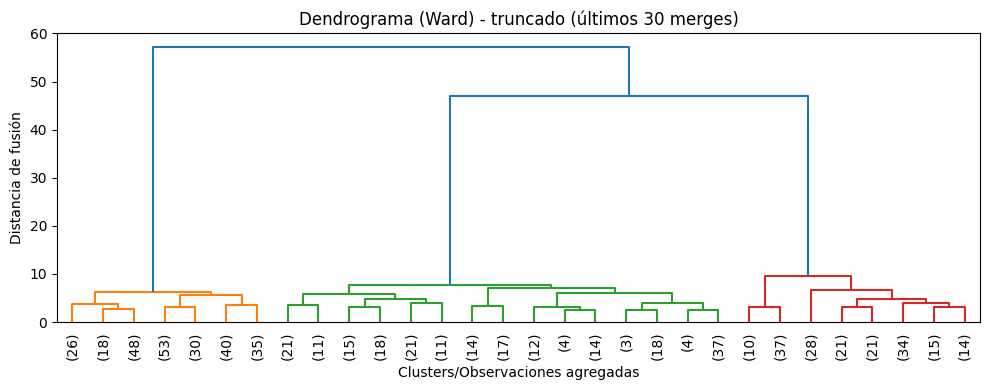

[Jerárquico] k=3 | Silueta=0.660


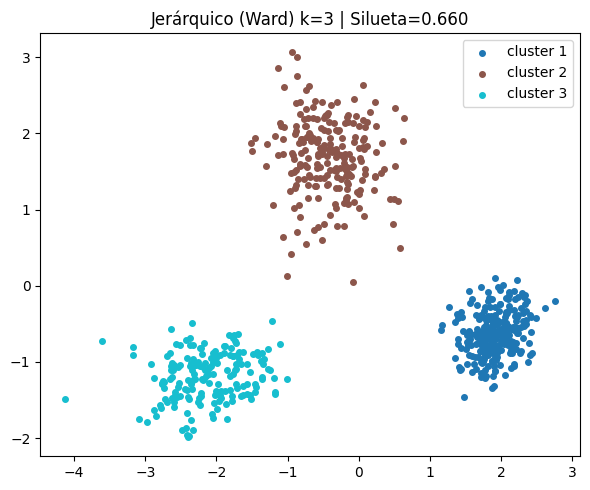

In [ ]:
# 2) APLICACIÓN DE ALGORITMOS
# ============================================================

# ---------------------------
# 2.1) JERÁRQUICO + DENDROGRAMA
# ---------------------------
print("\n>>> Clustering Jerárquico + Dendrograma (Ward)")
Z = linkage(X_std, method="ward", metric="euclidean")

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title("Dendrograma (Ward) - truncado (últimos 30 merges)")
plt.ylabel("Distancia de fusión")
plt.xlabel("Clusters/Observaciones agregadas")
plt.tight_layout(); plt.show()

# Elegir k cortando el dendrograma (AJUSTA este valor según 'altura' visual)
k_h = 3
labels_h = fcluster(Z, t=k_h, criterion="maxclust")
sil_h = silhouette_score(X_std, labels_h)
print(f"[Jerárquico] k={k_h} | Silueta={sil_h:.3f}")
plot_scatter_2d(X_pca, labels_h, f"Jerárquico (Ward) k={k_h} | Silueta={sil_h:.3f}")

Eje vertical → Distancia de fusión
Mide qué tan diferentes (o distantes) eran los grupos antes de fusionarse.

Distancias pequeñas (parte baja) indican que los grupos eran muy parecidos.

Distancias grandes (parte alta) indican que los grupos eran muy distintos.

Eje horizontal → Observaciones / Clusters
Cada número entre paréntesis es el ID de un cliente (o de un grupo de clientes).

Conforme subes, las ramas unen estos IDs en clusters más grandes.

Lectura del proceso
Comienza abajo: cada punto es un cliente individual.

A medida que subes, los clientes y grupos se van uniendo hasta formar un solo cluster.

El color de las ramas marca los clusters si se corta el dendrograma a cierta altura (por ejemplo, aquí parece que cortaron a una distancia que da 3 clusters: naranja, verde y rojo).

Interpretación práctica
Corte horizontal:
Si cortas el dendrograma en un punto de altura (distancia) determinada, los segmentos que quedan por debajo de ese corte son tus clusters finales.

Por ejemplo:

Si cortas a distancia ≈ 45, obtienes 3 clusters (los colores que ves).

Si cortas más abajo, obtendrás más clusters, pero serán más pequeños y homogéneos.

Si cortas más arriba, tendrás menos clusters, pero más heterogéneos.

Uso:
El dendrograma te ayuda a decidir cuántos clusters usar antes de aplicar clustering jerárquico sobre todos los datos.
En este ejemplo, la distancia de salto grande entre ≈ 45 y ≈ 55 sugiere que 3 grupos es una buena elección, ya que después la fusión implica unir grupos muy distintos.

**Interpretación del segundo gráfico:**
Ejes
Los ejes son componentes principales (PCA), no son las variables originales.

Sirven para representar en un plano 2D la relación entre los puntos, preservando en lo posible las distancias originales.

Colores y clusters
Azul (cluster 1), marrón (cluster 2) y celeste (cluster 3) son los grupos encontrados.

Los puntos dentro de cada color están más próximos entre sí que con los puntos de otros colores.

Separación de los grupos
Se observa que los 3 clusters están bien separados, lo que indica que el algoritmo identificó patrones claros en los datos.

La separación visual sugiere que los grupos tienen características internas distintas.

Índice de silueta = 0.660
El índice de silueta va de -1 a 1:

Cerca de 1 → los clusters están bien definidos y separados.

Cerca de 0 → los clusters se solapan.

Menor que 0 → los puntos están probablemente en el cluster equivocado.

0.660 es un valor bastante alto → muy buena calidad de agrupamiento.

Interpretación práctica
El cluster 2 (marrón) está en la parte central y probablemente representa un grupo intermedio en las variables originales (edad, ingresos, etc., en el dataset de clientes).

Los clusters 1 (azul) y 3 (celeste) están más a la derecha y más a la izquierda respectivamente, lo que indica perfiles más diferenciados (por ejemplo, clientes de alto ingreso y bajo gasto vs. bajo ingreso y alto gasto, según el dataset original).


>>> K-Means: método del codo + silueta


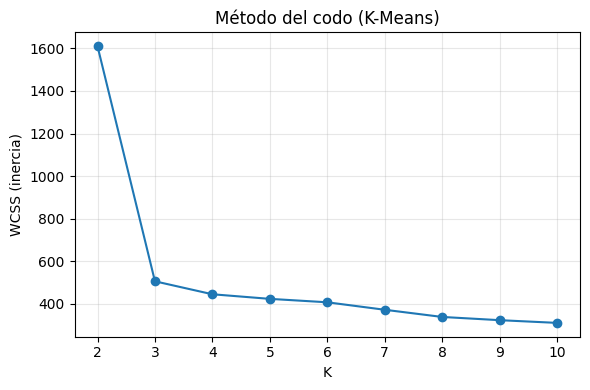

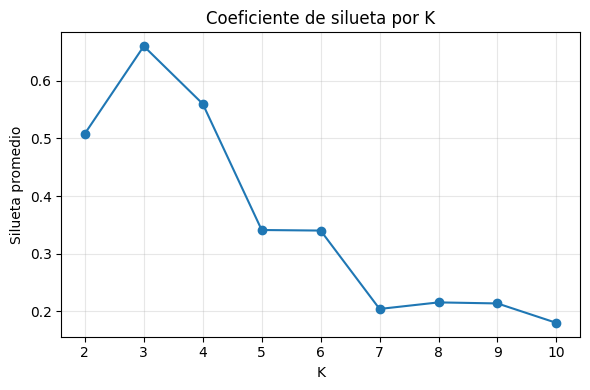

[K-Means] k*=3 (por silueta) | Silueta=0.660


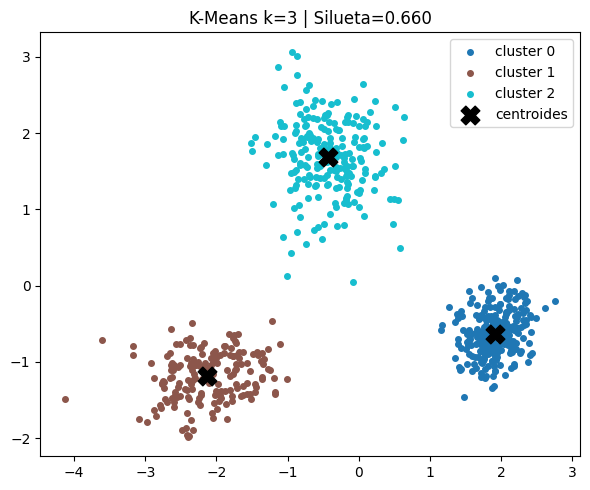

In [ ]:
# ---------------------------
# 2.2) K-MEANS: CODO + SILUETA + ENTRENAR
# ---------------------------
print("\n>>> K-Means: método del codo + silueta")
Ks = range(2, 11)
inertias, sils = [], []
for k in Ks:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels_k = km.fit_predict(X_std)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_std, labels_k))

# Plot codo
plt.figure(figsize=(6,4))
plt.plot(Ks, inertias, marker="o")
plt.xticks(Ks)
plt.xlabel("K"); plt.ylabel("WCSS (inercia)")
plt.title("Método del codo (K-Means)")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Plot silueta
plt.figure(figsize=(6,4))
plt.plot(Ks, sils, marker="o")
plt.xticks(Ks)
plt.xlabel("K"); plt.ylabel("Silueta promedio")
plt.title("Coeficiente de silueta por K")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Elegimos k por máxima silueta (puedes cruzar con el codo)
k_best = Ks[int(np.argmax(sils))]
km_best = KMeans(n_clusters=k_best, n_init="auto", random_state=42)
labels_km = km_best.fit_predict(X_std)
sil_km = silhouette_score(X_std, labels_km)
print(f"[K-Means] k*={k_best} (por silueta) | Silueta={sil_km:.3f}")
plot_scatter_2d(X_pca, labels_km, f"K-Means k={k_best} | Silueta={sil_km:.3f}", centers=km_best.cluster_centers_)

Qué muestra
Eje X (K): número de clusters probados (de 2 a 10 en este caso).

Eje Y (WCSS): Within-Cluster Sum of Squares, que mide la suma de las distancias cuadradas de cada punto a su centroide.

La idea es buscar un valor de K donde agregar más clusters no mejore mucho la reducción de WCSS.

Interpretación del gráfico
Entre K=2 y K=3 hay una gran caída de WCSS → se gana mucha homogeneidad interna al pasar de 2 a 3 clusters.

De K=3 a K=4 y posteriores, la reducción de WCSS es mucho más pequeña → las mejoras son marginales.

El “codo” está en K=3, lo que indica que este es el número óptimo de clusters para equilibrar simplicidad y calidad de agrupamiento.

Conclusión
K=3 es el valor recomendado.

Esto coincide con el clustering jerárquico que viste antes (también dio 3 clusters claros).

Usar más de 3 clusters probablemente fragmentaría grupos bien formados sin aportar valor significativo.

**Interpretación segundo gráfico:**
Qué mide el coeficiente de silueta
Oscila entre -1 y 1:

Cercano a 1 → los puntos están bien agrupados y bien separados de otros clusters.

Cercano a 0 → los puntos están en el límite entre clusters.

Negativo → los puntos están mal asignados.

Un valor alto indica que la estructura de clusters es más clara y definida.

Interpretación del gráfico
El valor más alto se da en K = 3 (~0.65), lo que indica que:

Hay buena separación entre clusters.

Los puntos están bien asignados a su grupo.

K=4 aún tiene buena silueta (~0.56), pero es un poco peor que K=3.

A partir de K=5, la silueta baja notablemente → los grupos empiezan a mezclarse o a no estar tan bien definidos.

K=2 tiene un valor razonable (~0.50), pero inferior a K=3.

Conclusión
Tanto por método del codo como por coeficiente de silueta, el número óptimo de clusters es K = 3.

Esto respalda que tu dataset tiene una estructura natural en tres grupos bien diferenciados.

**Interpretación tercer gráfico:**
Qué muestra el gráfico
Puntos de colores: representan las observaciones asignadas a cada cluster.

Azul (cluster 0), marrón (cluster 1) y celeste (cluster 2).

Cruces negras grandes (centroides): puntos centrales de cada cluster calculados por K-Means.

Título: indica el valor del coeficiente de silueta = 0.660, que mide qué tan bien separados y compactos están los clusters.

Interpretación
Los tres grupos están bien separados visualmente, lo que indica que la segmentación es clara.

La silueta de 0.660 es relativamente alta, señal de buena calidad de clustering.

Cada cluster presenta baja superposición con los otros, lo que significa que las características usadas para la agrupación logran diferenciar bien a los clientes.

Los centroides (cruces negras) son los promedios de cada grupo y actúan como referencia para asignar nuevos puntos.

Conclusión
K=3 fue una buena elección según tanto el método del codo como la silueta.

El modelo ha identificado tres segmentos bien diferenciados, lo que es útil para estrategias como marketing dirigido, personalización de productos o análisis de comportamiento de clientes.


>>> DBSCAN: k-distance plot + búsqueda de eps/min_samples


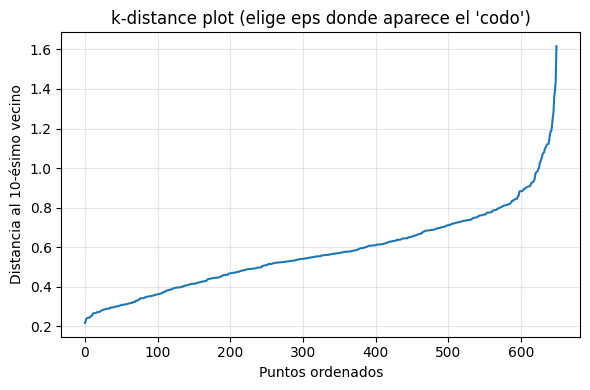

Sugerencia inicial eps (p95): 0.930

Resumen DBSCAN (primeras filas):


,eps,min_samples,n_clusters,silhouette
14,1.022549,12,3,0.624040
12,1.022549,8,3,0.624040
13,1.022549,10,3,0.624040
16,1.115508,10,3,0.621885
17,1.115508,12,3,0.621885
9,0.929590,8,3,0.605825
11,0.929590,12,3,0.605825
10,0.929590,10,3,0.605825
3,0.743672,8,3,0.588100
6,0.836631,8,3,0.587025


[DBSCAN] Mejor silueta=0.624 con eps=1.023, min_samples=8


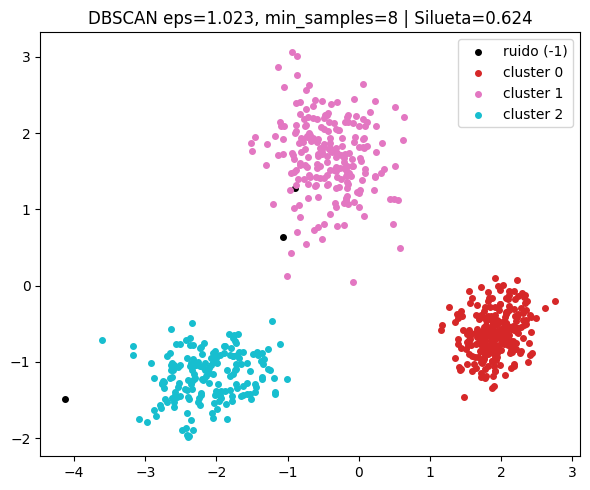

In [ ]:
# ---------------------------
# 2.3) DBSCAN: k-distance + barrido eps/min_samples
# ---------------------------
print("\n>>> DBSCAN: k-distance plot + búsqueda de eps/min_samples")
# Regla práctica: min_samples ~ 2*dim
min_samples = max(4, 2*X_std.shape[1])  # 2*#features
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_std)
distances, _ = nbrs.kneighbors(X_std)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(k_dist)
plt.ylabel(f"Distancia al {min_samples}-ésimo vecino")
plt.xlabel("Puntos ordenados")
plt.title("k-distance plot (elige eps donde aparece el 'codo')")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Sugerir eps por percentil alto (ajústalo si ves mucho ruido/pocos clusters)
eps_sug = float(np.percentile(k_dist, 95))
print(f"Sugerencia inicial eps (p95): {eps_sug:.3f}")

# Barrido de combinaciones para ver silueta (cuando hay >=2 clusters)
eps_grid = np.linspace(eps_sug*0.7, eps_sug*1.3, 7)
minpts_grid = [min_samples-2, min_samples, min_samples+2]
mejor = {"sil": -1, "eps": None, "minpts": None, "labels": None}
resumen_db = []

for eps in eps_grid:
    for mpts in minpts_grid:
        db = DBSCAN(eps=float(eps), min_samples=int(mpts))
        labels_db = db.fit_predict(X_std)
        # Contar clusters válidos (excluye ruido -1)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        if n_clusters >= 2:
            sil = silhouette_score(X_std, labels_db)
        else:
            sil = np.nan
        resumen_db.append((float(eps), int(mpts), n_clusters, sil))
        if np.isfinite(sil) and sil > mejor["sil"]:
            mejor.update({"sil": sil, "eps": float(eps), "minpts": int(mpts), "labels": labels_db})

# Mostrar top resultados DBSCAN
res_df = pd.DataFrame(resumen_db, columns=["eps","min_samples","n_clusters","silhouette"])
print("\nResumen DBSCAN (primeras filas):")
display(res_df.sort_values(["silhouette"], ascending=False).head(10))

if mejor["labels"] is not None:
    print(f"[DBSCAN] Mejor silueta={mejor['sil']:.3f} con eps={mejor['eps']:.3f}, min_samples={mejor['minpts']}")
    plot_scatter_2d(X_pca, mejor["labels"], f"DBSCAN eps={mejor['eps']:.3f}, min_samples={mejor['minpts']} | Silueta={mejor['sil']:.3f}")
else:
    print("[DBSCAN] No se detectaron >=2 clusters válidos con la malla actual. Ajusta eps/min_samples.")

**Primer gráfico:** Este gráfico es el k-distance plot y se usa para seleccionar el parámetro ε (eps) en el algoritmo DBSCAN.

Qué muestra
Eje X (Puntos ordenados): cada punto del dataset, ordenado según su distancia al k-ésimo vecino más cercano (en este caso, el 10º vecino).

Eje Y (Distancia al 10º vecino): la distancia entre cada punto y su décimo vecino más cercano.

La curva está ordenada de menor a mayor distancia.

Cómo interpretarlo
La idea es detectar un “codo” en la curva:

Antes del codo, las distancias aumentan de forma lenta y estable → puntos densamente conectados (pertenecen a clusters).

Después del codo, las distancias crecen rápido → puntos aislados (probables outliers o ruido).

El valor de ε (eps) se elige en la altura del codo.

En este gráfico, el “codo” se aprecia aproximadamente entre 0.8 y 0.9 en el eje Y.

Conclusión práctica
Para aplicar DBSCAN, un valor de eps ≈ 0.85 sería una buena elección inicial.

Este valor permitiría agrupar puntos que están dentro de esa distancia máxima, y separar como ruido los puntos más alejados.

****
Interpretación de la sugerencia inicial
Sugerencia inicial eps (p95): 0.930

Este valor proviene del análisis del k-distance plot, tomando aproximadamente el percentil 95 de las distancias al k-ésimo vecino.

Es un buen punto de partida porque suele capturar la mayoría de los puntos densos sin unir clusters que están lejos.

 Lectura de la tabla
Cada fila muestra:

eps → radio máximo para considerar puntos como vecinos.

min_samples → número mínimo de puntos para formar un cluster.

n_clusters → cantidad de clusters formados (sin contar el ruido, que DBSCAN marca como -1).

silhouette → calidad promedio de separación de los clusters (más cerca de 1, mejor).

Ejemplo:
eps=1.022549, min_samples=12 → 3 clusters, silueta=0.624040
Esto significa que con esos parámetros, DBSCAN encontró 3 grupos bien separados, con una buena cohesión y separación (0.62 es un valor alto para datos reales).

Patrones observados
eps entre 0.93 y 1.02 produce 3 clusters con silueta ≈ 0.605–0.624 → Muy consistentes y con buena separación.

eps demasiado bajo (ej. 0.74) baja la silueta a ≈ 0.588 y puede fragmentar clusters.

eps muy alto (mayor a 1.1) probablemente unirá clusters y reducirá la silueta (aunque no se muestran esos casos aquí).

Conclusión práctica
Un eps cercano a 1.0 y min_samples entre 8 y 12 parece dar el mejor equilibrio entre cantidad de clusters y calidad de separación para este dataset.

La sugerencia inicial (0.93) está dentro de ese rango, por lo que es un valor válido para comenzar y luego afinar.

**Interpretación segundo gráfico:**
Este gráfico muestra el resultado de aplicar DBSCAN con:

eps = 1.023

min_samples = 8

Silueta = 0.624 (buena separación y cohesión)

Interpretación
Número de clusters encontrados

cluster 0 (rojo) → grupo compacto, denso, bien definido.

cluster 1 (rosado) → grupo más disperso, pero igualmente cohesionado.

cluster 2 (celeste) → grupo bien delimitado y compacto.

ruido (-1) (negro) → puntos que no cumplen la densidad mínima y no pertenecen a ningún cluster (en este caso, 2 puntos aislados).

Calidad de la separación (Silueta 0.624)

Un valor de 0.62 indica que los puntos están mucho más cerca de su propio cluster que de otros clusters.

Este valor es alto para datos reales, lo que significa que DBSCAN segmentó bien la estructura.

Forma y densidad de los clusters

DBSCAN no asume formas esféricas, pero aquí los clusters son aproximadamente redondeados, lo que sugiere una distribución bastante regular.

El parámetro eps = 1.023 es suficiente para incluir la mayoría de los puntos de cada cluster sin fusionarlos con otros.

Ruido
Solo hay unos pocos puntos aislados (negros), lo que indica que el dataset está bien agrupado y no tiene demasiada dispersión.

Este modelo con eps=1.023 y min_samples=8 logra detectar 3 grupos principales bien separados y con mínima cantidad de ruido, lo que lo convierte en una configuración óptima para este dataset.


In [ ]:
# ============================================================
# 3) ANÁLISIS DE RESULTADOS
#    - Comparación de métodos y guías de interpretación
# ============================================================
print("\n>>> COMPARACIÓN Y GUÍA DE INTERPRETACIÓN")
print("""
[Comparación de métodos]
- Jerárquico (Ward):
  * Ventaja: no exige K a priori; el dendrograma muestra la jerarquía.
  * Elección de k: cortar a la 'altura' donde hay salto claro en distancias.
  * Útil cuando se busca entender la estructura jerárquica o subgrupos.

- K-Means:
  * Supone clusters convexos/esféricos y tamaños similares.
  * Selección de K: método del codo + pico de silueta.
  * Rápido y escalable; bueno con datos bien separados y variables escaladas.

- DBSCAN:
  * No requiere K; detecta formas arbitrarias y marca ruido (-1).
  * Parámetros clave: eps (radio) y min_samples (densidad).
  * Útil cuando hay outliers y formas complejas; sensible a la escala (¡estandariza!).

[Interpretación de patrones]
- Revisa los gráficos PCA 2D: clusters compactos y bien separados => siluetas más altas.
- Si DBSCAN devuelve mucho ruido, reduce eps o min_samples; si devuelve un único cluster, aumenta eps.
- Si Jerárquico con k=3 y K-Means k*=3 son parecidos, sugiere que existe una estructura tri-modal en los datos.

[Aplicabilidad]
- Usa K-Means cuando:
  * Buscas segmentación rápida con clusters 'redondeados' y de tamaño similar.
- Usa DBSCAN cuando:
  * Esperas outliers y formas no esféricas; no quieres fijar K.
- Usa Jerárquico cuando:
  * Necesitas interpretar jerarquías de similitud o decidir K visualmente con el dendrograma.
""")


>>> COMPARACIÓN Y GUÍA DE INTERPRETACIÓN

[Comparación de métodos]
- Jerárquico (Ward):
  * Ventaja: no exige K a priori; el dendrograma muestra la jerarquía.
  * Elección de k: cortar a la 'altura' donde hay salto claro en distancias.
  * Útil cuando se busca entender la estructura jerárquica o subgrupos.

- K-Means:
  * Supone clusters convexos/esféricos y tamaños similares.
  * Selección de K: método del codo + pico de silueta.
  * Rápido y escalable; bueno con datos bien separados y variables escaladas.

- DBSCAN:
  * No requiere K; detecta formas arbitrarias y marca ruido (-1).
  * Parámetros clave: eps (radio) y min_samples (densidad).
  * Útil cuando hay outliers y formas complejas; sensible a la escala (¡estandariza!).

[Interpretación de patrones]
- Revisa los gráficos PCA 2D: clusters compactos y bien separados => siluetas más altas.
- Si DBSCAN devuelve mucho ruido, reduce eps o min_samples; si devuelve un único cluster, aumenta eps.
- Si Jerárquico con k=3 y K-Means k*=3 s